In [ ]:
!pip install "astroquery>=0.4.11" astropy matplotlib numpy ipydatagrid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.7 MB/s eta 0:00:00
  Attempting uninstall: gast
    Found existing installation: gast 0.7.0
    Uninstalling gast-0.7.0:
      Successfully uninstalled gast-0.7.0


# **ESA EUCLID Archive**

[astroquery.esa.euclid](https://astroquery.readthedocs.io/en/latest/esa/euclid/euclid.html#module-astroquery.esa.euclid) provides the astroquery interface to the metadata and datasets provided by the European Space Agency EUCLID Archive using a TAP+ REST service. TAP+ is an extension of Table Access Protocol (TAP: http://www.ivoa.net/documents/TAP/) specified by the International Virtual Observatory Alliance (IVOA: http://www.ivoa.net).

The TAP query language is Astronomical Data Query Language (ADQL: https://www.ivoa.net/documents/ADQL/20231215/index.html ), which is similar to Structured Query Language (SQL), widely used to query databases.

## TAP provides two operation modes: Synchronous and Asynchronous

* **Synchronous**: the response to the request will be generated as soon as the request received by the server. (Do not use this method for queries that generate a large amount of results.)

* **Asynchronous**: the server starts a job that will execute the request. The first response to the request is the required information (a link) to obtain the job status. Once the job is finished, the results can be retrieved.

## ESA EUCLID TAP+ server provides two access modes: public and authenticated

* **Public**: this is the standard TAP access. A user can execute ADQL queries and upload tables to be used in a query ‘on-the-fly’ (these tables will be removed once the query is executed). The results are available to any other user, and they will remain in the server for a limited space of time.

* **Authenticated**: some functionalities are restricted to authenticated users only. The results are saved in a private user space and they will remain in the server forever (they can be removed by the user).

  * ADQL queries and results are saved in a user private area.

  * Persistence of uploaded tables: a user can upload a table in a private space. These tables can be used in queries as well as in cross-matches operations.

If you use public Euclid data in your paper, please take note of our guide on how to acknowledge and cite Euclid data.

## **MER = MERge Processing Function**
MER is the main Euclid source catalogue. The pipeline that merges all the Level-2 imaging information (VIS, NISP NIR, and external ground-based images) and builds a single multi-wavelength catalogue.

### What the MER catalogue contains (the “Final Catalog Product”)
The main catalogue produced by MER includes, for every detected object:

* Precise sky position (RA, Dec)

* Photometry in Euclid bands (VIS, Y, J, H)

* Photometry from ground-based surveys (ugriz and similar, depending on field)

* Various morphological parameters (sizes, Sérsic fits, shapes, flags, etc.)

* Quality flags and ancillary info used by other pipelines.

# **Imports**

In [ ]:
import sys
import os
import random
from pathlib import Path

from google.colab import output
output.enable_custom_widget_manager()

import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.io.votable import parse
from astropy.table import Table
from astroquery.esa.euclid import Euclid, conf
from astropy.visualization import astropy_mpl_style, ImageNormalize, PercentileInterval, AsinhStretch, LogStretch

from astroquery.esa.euclid import Euclid

# Limit rows returned in queries
Euclid.ROW_LIMIT = 50

print("Euclid environment:", "PDR (public Q1)")
print("Euclid TAP base URL:", conf.ENVIRONMENTS["PDR"]["url_server"])

Euclid environment: PDR (public Q1)
Euclid TAP base URL: https://eas.esac.esa.int/


In [ ]:
Euclid.login()

INFO:astroquery:Login to Euclid TAP server: eas.esac.esa.int:443/tap-server/tap/


INFO: Login to Euclid TAP server: eas.esac.esa.int:443/tap-server/tap/ [astroquery.esa.euclid.core]
User: imolera
Password: ··········


INFO:astroquery:OK
INFO:astroquery:Login to Euclid data service: eas.esac.esa.int:443/sas-dd/tap-server/


INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid data service: eas.esac.esa.int:443/sas-dd/tap-server/ [astroquery.esa.euclid.core]


INFO:astroquery:OK
INFO:astroquery:Login to Euclid cutout service: eas.esac.esa.int:443/sas-cutout/tap-server/


INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid cutout service: eas.esac.esa.int:443/sas-cutout/tap-server/ [astroquery.esa.euclid.core]


INFO:astroquery:OK


INFO: OK [astroquery.utils.tap.core]


# **Synchronous query**

In [ ]:
# query content: getting some galaxies from the mer catalogue
query = (
    "SELECT right_ascension, declination, segmentation_area, fluxerr_vis_1fwhm_aper, ellipticity, kron_radius "
    "FROM catalogue.mer_catalogue "
    "WHERE ellipticity > 0 "
    "ORDER BY ellipticity ASC"
)

## Query without saving results in a file:


In [ ]:
job = Euclid.launch_job(query)
source_results_table = job.get_results()

print("Found", len(source_results_table), "query results")
print("The results table includes the following", len(source_results_table.colnames), "columns: ", source_results_table.colnames)
print(source_results_table[:15])

Found 2000 query results
The results table includes the following 6 columns:  ['right_ascension', 'declination', 'segmentation_area', 'fluxerr_vis_1fwhm_aper', 'ellipticity', 'kron_radius']
 right_ascension       declination     ...    kron_radius    
------------------ ------------------- ... ------------------
  60.3372780005097  -49.93184727724773 ... 10.145233154296875
 59.92581284609097 -48.117835930359156 ... 10.814051628112793
 62.91963955425831  -45.60370330289406 ...  884.3989868164062
 54.38946012012026 -28.843720993232775 ...  11.36937141418457
 267.3583266451287  63.994872950197674 ... 10.564066886901855
52.507667893100944 -29.445192357858655 ... 10.120616912841797
 61.43102565450044  -48.13296805386111 ... 10.149212837219238
274.03172675714404   65.86352270374569 ... 10.804966926574707
 271.4749139468259   68.66799925831447 ... 15.325024604797363
 64.08716465009101  -47.39574129846509 ...  8.137764930725098
 62.46388138426946 -48.771499634650795 ...  12.14012336730957
 59.

## Query saving results in a file:

In [ ]:
job = Euclid.launch_job(query, dump_to_file=True, output_format='votable')
print(job.outputFile)
r = job.get_results()
print(r)

1771105902030TPDR-result.vot
 right_ascension       declination     ...    kron_radius    
       deg                 deg         ...        pix        
------------------ ------------------- ... ------------------
  60.3372780005097  -49.93184727724773 ... 10.145233154296875
 59.92581284609097 -48.117835930359156 ... 10.814051628112793
 62.91963955425831  -45.60370330289406 ...  884.3989868164062
 54.38946012012026 -28.843720993232775 ...  11.36937141418457
 267.3583266451287  63.994872950197674 ... 10.564066886901855
52.507667893100944 -29.445192357858655 ... 10.120616912841797
 61.43102565450044  -48.13296805386111 ... 10.149212837219238
274.03172675714404   65.86352270374569 ... 10.804966926574707
 271.4749139468259   68.66799925831447 ... 15.325024604797363
               ...                 ... ...                ...
61.711830300726746   -50.0470758569644 ... 13.654233932495117
 63.83087207233427  -48.50545139595399 ... 10.791407585144043
 59.03874075769185 -50.681646843378964 ..

## Reading from .vot file:

In [ ]:
vot = parse(job.outputFile)
tab = vot.get_first_table().to_table()
# print(tab)

t = Table.read(job.outputFile, format="votable")
# print(t)

# HTML table
t.show_in_notebook()

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

## Convert .vot to .csv:

In [ ]:
t.write("my_file.csv", format="csv", overwrite=True)

## Query object:

The following example searches for all the sources contained in an squared region of side = 0.1 degrees around a specific point in ra/dec coordinates. The results are sorted by distance (dist) in ascending order.

The method returns the job results as astropy.table

In [ ]:
# Coordinates in the Euclid Deep Field South (example in the Euclid docs)
# https://astroquery.readthedocs.io/en/latest/esa/euclid/euclid.html
coord = SkyCoord(
    ra=60.3372780005097,
    dec=-49.93184727724773,
    unit=(u.degree, u.degree),
    frame="icrs",
)

width  = 0.1 * u.deg
height = 0.1 * u.deg

print("Querying Q1 MER catalogue around:", coord.to_string("hmsdms"))
table = Euclid.query_object(
    coordinate=coord,
    width=width,
    height=height,
    # default: catalogue.mer_catalogue
    # , async_job=False
)

print("Rows returned:", len(table))
table[:5]

Querying Q1 MER catalogue around: 04h01m20.94672012s -49d55m54.65019809s


Rows returned: 50


dist,basic_download_data_oid,to_be_published,object_id,right_ascension,declination,right_ascension_psf_fitting,declination_psf_fitting,segmentation_map_id,vis_det,flux_vis_1fwhm_aper,flux_vis_2fwhm_aper,flux_vis_3fwhm_aper,flux_vis_4fwhm_aper,flux_y_1fwhm_aper,flux_y_2fwhm_aper,flux_y_3fwhm_aper,flux_y_4fwhm_aper,flux_j_1fwhm_aper,flux_j_2fwhm_aper,flux_j_3fwhm_aper,flux_j_4fwhm_aper,flux_h_1fwhm_aper,flux_h_2fwhm_aper,flux_h_3fwhm_aper,flux_h_4fwhm_aper,flux_nir_stack_1fwhm_aper,flux_nir_stack_2fwhm_aper,flux_nir_stack_3fwhm_aper,flux_nir_stack_4fwhm_aper,flux_u_ext_decam_1fwhm_aper,flux_u_ext_decam_2fwhm_aper,flux_u_ext_decam_3fwhm_aper,flux_u_ext_decam_4fwhm_aper,flux_g_ext_decam_1fwhm_aper,flux_g_ext_decam_2fwhm_aper,flux_g_ext_decam_3fwhm_aper,flux_g_ext_decam_4fwhm_aper,flux_r_ext_decam_1fwhm_aper,flux_r_ext_decam_2fwhm_aper,flux_r_ext_decam_3fwhm_aper,flux_r_ext_decam_4fwhm_aper,flux_i_ext_decam_1fwhm_aper,flux_i_ext_decam_2fwhm_aper,flux_i_ext_decam_3fwhm_aper,flux_i_ext_decam_4fwhm_aper,flux_z_ext_decam_1fwhm_aper,flux_z_ext_decam_2fwhm_aper,flux_z_ext_decam_3fwhm_aper,flux_z_ext_decam_4fwhm_aper,flux_u_ext_lsst_1fwhm_aper,flux_u_ext_lsst_2fwhm_aper,flux_u_ext_lsst_3fwhm_aper,flux_u_ext_lsst_4fwhm_aper,flux_g_ext_lsst_1fwhm_aper,flux_g_ext_lsst_2fwhm_aper,flux_g_ext_lsst_3fwhm_aper,flux_g_ext_lsst_4fwhm_aper,flux_r_ext_lsst_1fwhm_aper,flux_r_ext_lsst_2fwhm_aper,flux_r_ext_lsst_3fwhm_aper,flux_r_ext_lsst_4fwhm_aper,flux_i_ext_lsst_1fwhm_aper,flux_i_ext_lsst_2fwhm_aper,flux_i_ext_lsst_3fwhm_aper,flux_i_ext_lsst_4fwhm_aper,flux_z_ext_lsst_1fwhm_aper,flux_z_ext_lsst_2fwhm_aper,flux_z_ext_lsst_3fwhm_aper,flux_z_ext_lsst_4fwhm_aper,flux_u_ext_megacam_1fwhm_aper,flux_u_ext_megacam_2fwhm_aper,flux_u_ext_megacam_3fwhm_aper,flux_u_ext_megacam_4fwhm_aper,flux_r_ext_megacam_1fwhm_aper,flux_r_ext_megacam_2fwhm_aper,flux_r_ext_megacam_3fwhm_aper,flux_r_ext_megacam_4fwhm_aper,flux_g_ext_jpcam_1fwhm_aper,flux_g_ext_jpcam_2fwhm_aper,flux_g_ext_jpcam_3fwhm_aper,flux_g_ext_jpcam_4fwhm_aper,flux_i_ext_panstarrs_1fwhm_aper,flux_i_ext_panstarrs_2fwhm_aper,flux_i_ext_panstarrs_3fwhm_aper,flux_i_ext_panstarrs_4fwhm_aper,flux_z_ext_panstarrs_1fwhm_aper,flux_z_ext_panstarrs_2fwhm_aper,flux_z_ext_panstarrs_3fwhm_aper,flux_z_ext_panstarrs_4fwhm_aper,flux_g_ext_hsc_1fwhm_aper,flux_g_ext_hsc_2fwhm_aper,flux_g_ext_hsc_3fwhm_aper,flux_g_ext_hsc_4fwhm_aper,flux_z_ext_hsc_1fwhm_aper,flux_z_ext_hsc_2fwhm_aper,flux_z_ext_hsc_3fwhm_aper,flux_z_ext_hsc_4fwhm_aper,fluxerr_vis_1fwhm_aper,fluxerr_vis_2fwhm_aper,fluxerr_vis_3fwhm_aper,fluxerr_vis_4fwhm_aper,fluxerr_y_1fwhm_aper,fluxerr_y_2fwhm_aper,fluxerr_y_3fwhm_aper,fluxerr_y_4fwhm_aper,fluxerr_j_1fwhm_aper,fluxerr_j_2fwhm_aper,fluxerr_j_3fwhm_aper,fluxerr_j_4fwhm_aper,fluxerr_h_1fwhm_aper,fluxerr_h_2fwhm_aper,fluxerr_h_3fwhm_aper,fluxerr_h_4fwhm_aper,fluxerr_nir_stack_1fwhm_aper,fluxerr_nir_stack_2fwhm_aper,fluxerr_nir_stack_3fwhm_aper,fluxerr_nir_stack_4fwhm_aper,fluxerr_u_ext_decam_1fwhm_aper,fluxerr_u_ext_decam_2fwhm_aper,fluxerr_u_ext_decam_3fwhm_aper,fluxerr_u_ext_decam_4fwhm_aper,fluxerr_g_ext_decam_1fwhm_aper,fluxerr_g_ext_decam_2fwhm_aper,fluxerr_g_ext_decam_3fwhm_aper,fluxerr_g_ext_decam_4fwhm_aper,fluxerr_r_ext_decam_1fwhm_aper,fluxerr_r_ext_decam_2fwhm_aper,fluxerr_r_ext_decam_3fwhm_aper,fluxerr_r_ext_decam_4fwhm_aper,fluxerr_i_ext_decam_1fwhm_aper,fluxerr_i_ext_decam_2fwhm_aper,fluxerr_i_ext_decam_3fwhm_aper,fluxerr_i_ext_decam_4fwhm_aper,fluxerr_z_ext_decam_1fwhm_aper,fluxerr_z_ext_decam_2fwhm_aper,fluxerr_z_ext_decam_3fwhm_aper,fluxerr_z_ext_decam_4fwhm_aper,fluxerr_u_ext_lsst_1fwhm_aper,fluxerr_u_ext_lsst_2fwhm_aper,fluxerr_u_ext_lsst_3fwhm_aper,fluxerr_u_ext_lsst_4fwhm_aper,fluxerr_g_ext_lsst_1fwhm_aper,fluxerr_g_ext_lsst_2fwhm_aper,fluxerr_g_ext_lsst_3fwhm_aper,fluxerr_g_ext_lsst_4fwhm_aper,fluxerr_r_ext_lsst_1fwhm_aper,fluxerr_r_ext_lsst_2fwhm_aper,fluxerr_r_ext_lsst_3fwhm_aper,fluxerr_r_ext_lsst_4fwhm_aper,fluxerr_i_ext_lsst_1fwhm_aper,fluxerr_i_ext_lsst_2fwhm_aper,fluxerr_i_ext_lsst_3f

# **Plot Euclid images**

## Getting metadata

In [ ]:
product_list_results = Euclid.get_product_list(tile_index="102018211", product_type="DpdMerBksMosaic")
print("Found", len(product_list_results), "results")
print(product_list_results)
#print("Column names: ", product_list_results.colnames)
print(product_list_results[0])

Found 8 results
                                    file_name                                      ...
                                                                                   ...
---------------------------------------------------------------------------------- ...
EUC_MER_BGSUB-MOSAIC-DES-Z_TILE102018211-83C32F_20241018T143526.104818Z_00.00.fits ...
EUC_MER_BGSUB-MOSAIC-DES-G_TILE102018211-D9D163_20241018T143010.768685Z_00.00.fits ...
  EUC_MER_BGSUB-MOSAIC-VIS_TILE102018211-ACBD03_20241018T142710.276838Z_00.00.fits ...
EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102018211-E044A1_20241018T142600.459089Z_00.00.fits ...
EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102018211-42F1AD_20241018T142558.469987Z_00.00.fits ...
EUC_MER_BGSUB-MOSAIC-DES-I_TILE102018211-31E2C9_20241018T143048.358037Z_00.00.fits ...
EUC_MER_BGSUB-MOSAIC-DES-R_TILE102018211-1078B7_20241018T142927.232351Z_00.00.fits ...
EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102018211-E5CAE1_20241018T142558.172837Z_00.00.fits ...
                           

In [ ]:
example_file_name = str(product_list_results[0]["file_name"])
print(example_file_name)

EUC_MER_BGSUB-MOSAIC-DES-Z_TILE102018211-83C32F_20241018T143526.104818Z_00.00.fits


Download an product (image) by its file name:

In [ ]:
output_folder= 'example_outputs/'
if not os.path.exists(output_folder):
       os.makedirs(output_folder)

#example_file_name = "EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102158889-ED035A_20241024T212936.705156Z_00.00.fits"
print("Getting file:", example_file_name)
path = Euclid.get_product(file_name=example_file_name, output_file=output_folder + example_file_name,verbose=True)

# !!! The following code will crash Colab !!!

'''
hdul = fits.open(path[0])
print(fits.info(path[0]))
image_data = hdul[0].data

plt.figure()
plt.imshow(image_data, cmap='gray', origin='lower', norm=ImageNormalize(image_data, interval=PercentileInterval(99.9), stretch=AsinhStretch()))
colorbar = plt.colorbar()
'''

Getting file: EUC_MER_BGSUB-MOSAIC-DES-Z_TILE102018211-83C32F_20241018T143526.104818Z_00.00.fits
Retrieving data.
Data request: TAPCLIENT=ASTROQUERY&RELEASE=sedm&FILE_NAME=EUC_MER_BGSUB-MOSAIC-DES-Z_TILE102018211-83C32F_20241018T143526.104818Z_00.00.fits&RETRIEVAL_TYPE=FILE
------>https
host = eas.esac.esa.int:443
context = /sas-dd/data
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.


"\nhdul = fits.open(path[0])\nprint(fits.info(path[0]))\nimage_data = hdul[0].data\n\nplt.figure()\nplt.imshow(image_data, cmap='gray', origin='lower', norm=ImageNormalize(image_data, interval=PercentileInterval(99.9), stretch=AsinhStretch()))\ncolorbar = plt.colorbar()\n"

# **Cone search**

This query performs a cone search centered at the specified ra/dec coordinates with the provided radius argument.

In [ ]:
coord = SkyCoord("17h51m07.4s +65d31m50.8s", frame='icrs')
radius = u.Quantity(0.5, u.deg)

job = Euclid.cone_search(
    coordinate=coord,
    radius=radius,
    table_name="sedm.mosaic_product",
    ra_column_name="ra",
    dec_column_name="dec",
    columns="*",
    async_job=True
)

cone_results = job.get_results()
print("Found", len(cone_results), "results")

cone_results['tile_index', 'creation_date', 'ra', 'dec', 'file_name', 'file_path', 'datalabs_path', 'filter_name', 'dist'][:5]

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Found 27 results


tile_index,creation_date,ra,dec,file_name,file_path,datalabs_path,filter_name,dist
int64,str23,float64,float64,str88,str55,str43,str11,float64
102158889,2024-10-26T14:01:21.038,267.3807789,65.4983,EUC_MER_BGSUB-MOSAIC-CFIS-R_TILE102158889-4366B7_20241024T203624.450577Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/MEGACAM,/data/euclid_q1/Q1_R1/MER/102158889/MEGACAM,MEGACAM_r,0.16895922479034217
102158889,2024-10-26T12:57:21.177,267.3807789,65.4983,EUC_MER_BGSUB-MOSAIC-VIS_TILE102158889-F95D3B_20241025T024806.508980Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/VIS,/data/euclid_q1/Q1_R1/MER/102158889/VIS,VIS,0.16895922479034217
102158889,2024-10-26T13:56:42.846,267.3807789,65.4983,EUC_MER_BGSUB-MOSAIC-WISHES-Z_TILE102158889-60A7E6_20241024T204143.931276Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/HSC,/data/euclid_q1/Q1_R1/MER/102158889/HSC,HSC_z,0.16895922479034217
102158889,2024-10-26T14:08:43.976,267.3807789,65.4983,EUC_MER_BGSUB-MOSAIC-PANSTARRS-I_TILE102158889-5BC663_20241024T203110.498476Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/GPC,/data/euclid_q1/Q1_R1/MER/102158889/GPC,PANSTARRS_i,0.16895922479034217
102158889,2024-10-26T13:24:14.889,267.3807789,65.4983,EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102158889-B8D44B_20241024T215040.579149Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/NISP,/data/euclid_q1/Q1_R1/MER/102158889/NISP,NIR_J,0.16895922479034217


# **Cutout search**

To download a cutout given its file path, instrument and obs_id, and the cutout region, the method downloads the fits file of the cutout and returns a list containing the local path where the cutout is saved.

category             checksum                  creation_date      crpix1 crpix2    crval1    crval2              datalabs_path              data_release_oid data_size   dec                                      file_name                                                          file_path                      filter_name first_type                                                                            fov                                                                            instrument_name mosaic_product_oid patch_id_list                                                   product_id                                                     product_type  provenance_id published      ra     release_date release_name second_type                                                                              stc_s                                                                               technique tile_index to_be_published zero_point zero_point_error         dist       
-------- ----------

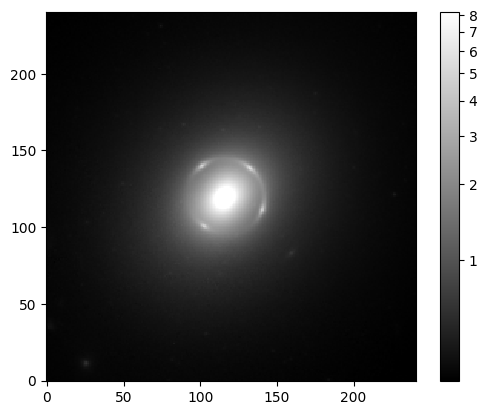

In [ ]:
example_file = cone_results[cone_results['instrument_name'] == 'VIS'][0]
print(example_file)

# getting the arguments from the cone search result table automatically
file_path=example_file["file_path"] + "/" + example_file["file_name"]
print("file_path = ", file_path)
# /euclid/repository_idr/iqr1/Q1_R1/MER/102158889/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102158889-F95D3B_20241025T024806.508980Z_00.00.fits

instrument=example_file["instrument_name"]
# VIS

obs_id=example_file["tile_index"]
print("obs_id = ", obs_id)
# 102158889

radius= 0.2 * u.arcmin
coord = SkyCoord("17h51m07.4s +65d31m50.8s", frame='icrs')
print(coord)
# SkyCoord (ICRS): (ra, dec) in deg (267.78083333, 65.53077778)

output_folder= 'example_outputs/'
if not os.path.exists(output_folder):
       os.makedirs(output_folder)
output_file=output_folder + 'cutouts/astroquery_cutout_example.fits'

saved_cutout_filepath = Euclid.get_cutout(file_path=file_path, instrument=instrument, id=obs_id, coordinate=coord, radius=radius, output_file=output_file)
print("Cutout saved at", saved_cutout_filepath)

# looking at the cutout
hdul = fits.open(saved_cutout_filepath[0])
print(fits.info(saved_cutout_filepath[0]))

image_data = hdul[0].data

plt.imshow(image_data, interpolation='nearest', cmap='gray', origin='lower', norm=ImageNormalize(image_data, interval=PercentileInterval(99.5), stretch=AsinhStretch()))
plt.colorbar()

In [ ]:
def make_and_show_cutouts(
    n_cutouts,
    coord,
    cone_radius,
    cutout_radius,
    instrument_name="VIS",
    table_name="sedm.mosaic_product",
    output_dir="example_outputs/cutouts",
    center_on_mosaic=True,
):
    """
    Generate up to `n_cutouts` valid cutouts and display them.
    If center_on_mosaic=True, each cutout is centered on that mosaic's RA/Dec
    instead of the fixed `coord`.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Running cone_search around {coord.to_string('hmsdms')}, "
          f"radius={cone_radius}, table={table_name}")

    job = Euclid.cone_search(
        coordinate=coord,
        radius=cone_radius,
        table_name=table_name,
        ra_column_name="ra",
        dec_column_name="dec",
        columns="*",
        async_job=True,
    )

    cone_results = job.get_results()
    print("Total results:", len(cone_results))

    mask = cone_results["instrument_name"] == instrument_name
    vis_results = cone_results[mask]

    print(f"Results with instrument={instrument_name!r}:", len(vis_results))
    if len(vis_results) == 0:
        print("No results for this instrument, nothing to do.")
        return

    print(f"Trying to generate up to {n_cutouts} cutouts from "
          f"{len(vis_results)} {instrument_name} mosaics...")

    valid_count = 0

    for idx, row in enumerate(vis_results):
        if valid_count >= n_cutouts:
            break

        file_path = f"{row['file_path']}/{row['file_name']}"
        obs_id = row["tile_index"]
        filt = row["filter_name"]

        # --- choose center for this cutout ---
        if center_on_mosaic:
            cut_coord = SkyCoord(row["ra"], row["dec"], unit=("deg", "deg"), frame="icrs")
        else:
            cut_coord = coord
        # -------------------------------------

        out_name = f"cutout_{valid_count+1}_{instrument_name}_{obs_id}_{filt}.fits"
        output_file = output_dir / out_name

        print(f"\n[{valid_count+1}/{n_cutouts}] Requesting cutout for {file_path}")
        print(f"  -> obs_id={obs_id}, filter={filt}, radius={cutout_radius}, "
              f"center={cut_coord.to_string('hmsdms')}")

        try:
            saved_paths = Euclid.get_cutout(
                file_path=file_path,
                instrument=instrument_name,
                id=obs_id,
                coordinate=cut_coord,
                radius=cutout_radius,
                output_file=str(output_file),
            )
        except Exception as e:
            print("  !! Cutout request failed, skipping:", e)
            continue

        if not saved_paths:
            print("  !! No files returned for this cutout, skipping.")
            continue

        fits_candidates = [Path(p) for p in saved_paths if str(p).lower().endswith(".fits")]
        if not fits_candidates:
            print("  !! No FITS files returned:", saved_paths)
            continue

        cutout_path = fits_candidates[0]
        print("  Cutout saved at", cutout_path)

        try:
            with fits.open(cutout_path) as hdul:
                image_data = hdul[0].data
        except OSError as e:
            print("  !! Skipping invalid FITS file:", e)
            continue

        valid_count += 1

        norm = ImageNormalize(
            image_data,
            interval=PercentileInterval(99.5),
            stretch=AsinhStretch(),
        )

        plt.figure(figsize=(6, 6))
        plt.imshow(
            image_data,
            interpolation="nearest",
            cmap="gray",
            origin="lower",
            norm=norm,
        )
        plt.title(f"{instrument_name} {obs_id} {filt} (cutout {valid_count})")
        plt.colorbar(label="Counts")

    if valid_count == 0:
        print("\nNo valid FITS cutouts were produced.")
    else:
        print(f"\nSuccessfully displayed {valid_count} cutout(s).")
        plt.show()

Running cone_search around 17h51m07.4s +65d31m50.8s, radius=0.5 deg, table=sedm.mosaic_product


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Total results: 27
Results with instrument='VIS': 3
Trying to generate up to 3 cutouts from 3 VIS mosaics...

[1/3] Requesting cutout for /euclid/repository_idr/iqr1/Q1_R1/MER/102158889/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102158889-F95D3B_20241025T024806.508980Z_00.00.fits
  -> obs_id=102158889, filter=VIS, radius=0.2 arcmin, center=17h49m31.386936s +65d29m53.88s
  Cutout saved at example_outputs/cutouts/cutout_1_VIS_102158889_VIS.fits

[2/3] Requesting cutout for /euclid/repository_idr/iqr1/Q1_R1/MER/102158890/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102158890-A009F7_20241025T033856.531554Z_00.00.fits
  -> obs_id=102158890, filter=VIS, radius=0.2 arcmin, center=17h54m15.331128s +65d30m00s
  Cutout saved at example_outputs/cutouts/cutout_2_VIS_102158890_VIS.fits

[3/3] Requesting cutout for /euclid/repository_idr/iqr1/Q1_R1/MER/102159190/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102159190-6E6EF8_20241025T010045.358775Z_00.00.fits
  -> obs_id=102159190, filt

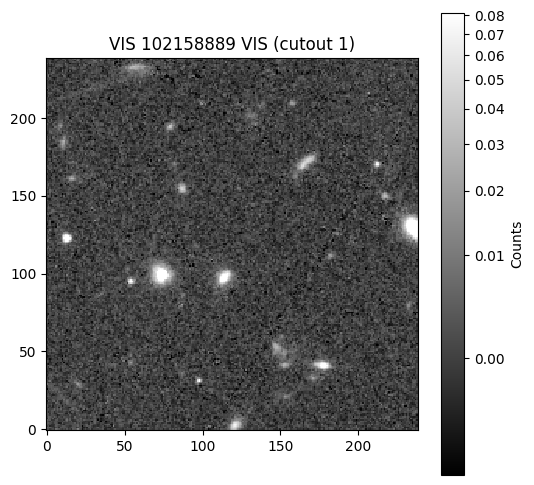

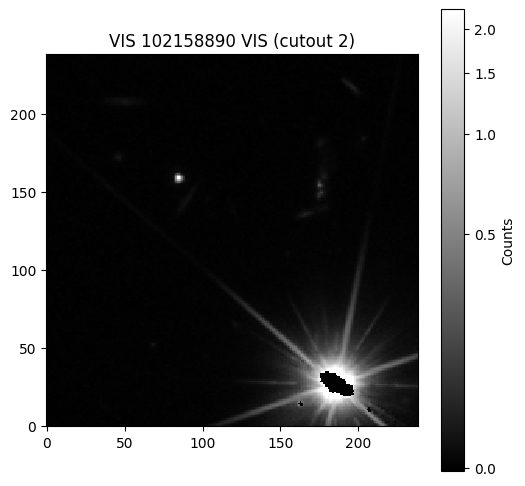

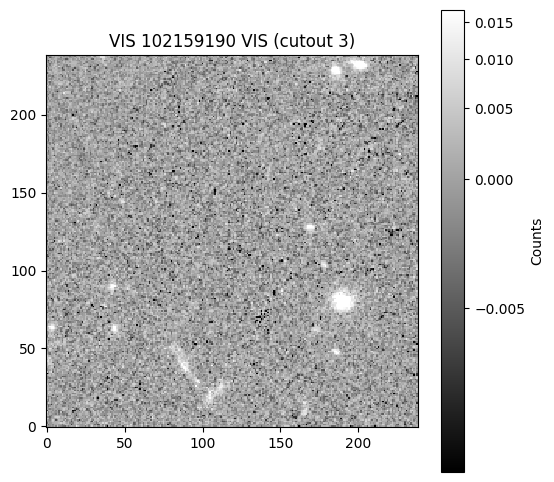

In [ ]:
coord = SkyCoord("17h51m07.4s +65d31m50.8s", frame="icrs")
cone_radius   = 0.5 * u.deg
cutout_radius = 0.2 * u.arcmin

make_and_show_cutouts(
    n_cutouts=3,
    coord=coord,
    cone_radius=cone_radius,
    cutout_radius=cutout_radius,
    instrument_name="VIS",
    center_on_mosaic=True,
)